<a href="https://colab.research.google.com/github/mdnestor/idesim/blob/master/idesim_notes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#!git clone https://github.com/mdnestor/ide-ptws
#import sys
#sys.path.insert(0,'/content/ide-ptws')

import numpy as np
from ide import IDE
from ide import IDESimulation

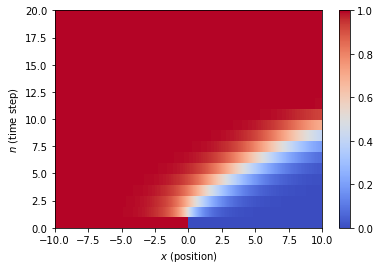

C:\Users\vilim\OneDrive\ide-ptws\ide.py:69: RuntimeWarning: invalid value encountered in true_divide
  Z /= np.sign(Z)


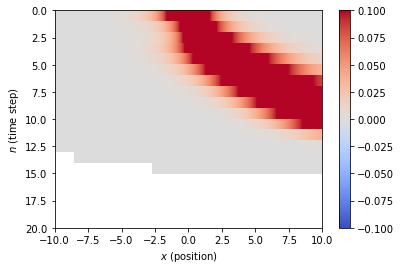

In [2]:
def logistic(r = 1):
    return lambda x: x + r * x * (1 - x)

def laplace(sigma = 1):
    return lambda x : sigma/2 * np.exp(-sigma * np.abs(x))

def heaviside(a = 0):
    return lambda x: np.heaviside(x - a, 1)

ide = IDE(growth_fn = logistic(r = 1),
          kernel_fn = laplace())

IDESimulation(ide, initial_condition = heaviside(), num_iters = 20, domain_size = 20, step_size = 1e-2)

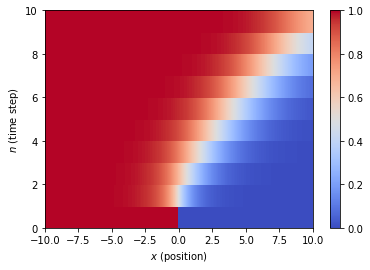

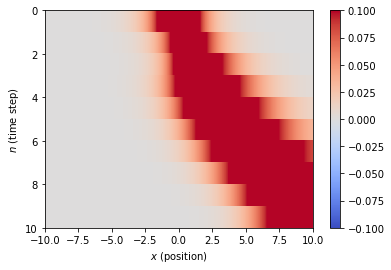

In [3]:
IDESimulation(ide, initial_condition = lambda x : np.heaviside(x, 1),
              num_iters = 10, domain_size = 20, step_size = 1e-2)

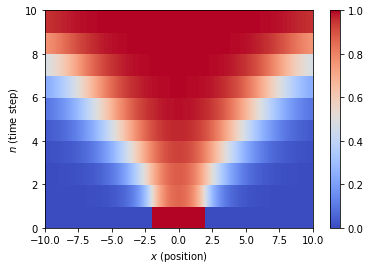

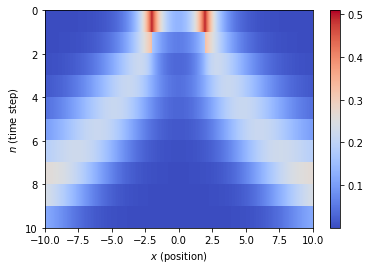

In [4]:
r0 = 2
IDESimulation(ide, initial_condition = lambda x: np.heaviside(r0 - np.abs(x), 1),
              num_iters = 10, domain_size = 20, step_size = 0.005)

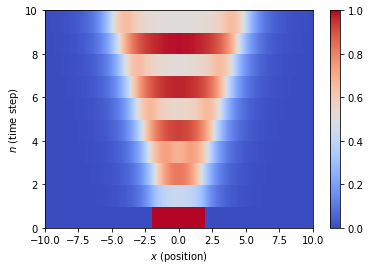

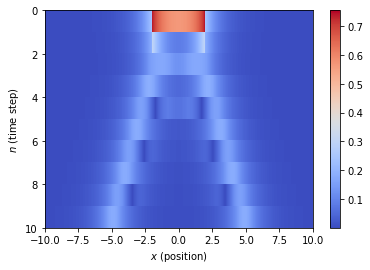

In [6]:
otto_growth = lambda a, m, b: lambda x: np.heaviside(x - a, 1) - (1 - m) * np.heaviside(x - b, 1)

ide = IDE(growth_fn = otto_growth(a = 0.3, m = 0.5, b = 0.8),
          kernel_fn = laplace())

r0 = 2
sim = IDESimulation(ide, initial_condition = lambda x: np.heaviside(r0 - np.abs(x), 1),
                    num_iters = 10, domain_size = 20, step_size = 0.005)

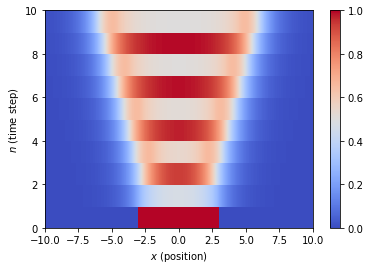

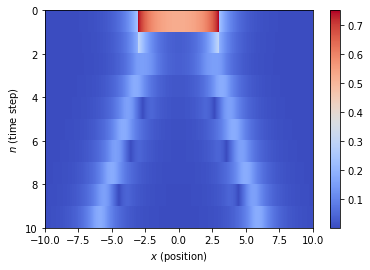

In [7]:
ide = IDE(growth_fn = otto_growth(a = 0.3, m = 0.5, b = 0.8),
          kernel_fn = laplace())
r0 = 3
IDESimulation(ide, initial_condition = lambda x: np.heaviside(r0 - np.abs(x), 1),
              num_iters = 10, domain_size = 20, step_size = 0.005)

In [8]:
ricker = lambda r: lambda u: u * np.exp(r * (1 - u))

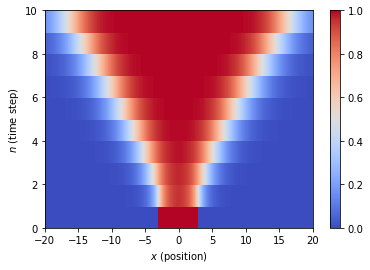

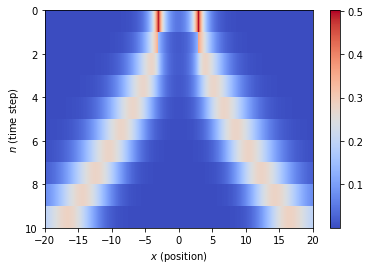

In [12]:
def u0_compact(r):
    return lambda x: np.heaviside(r - np.abs(x), 1)

ide = IDE(growth_fn         = ricker(r = 1),
             kernel_fn         = laplace(),)

sim = IDESimulation(ide       = ide,
                    initial_condition = u0_compact(r = 3),
                    num_iters = 10,
                  domain_size = 40,  
                    step_size = 0.01)

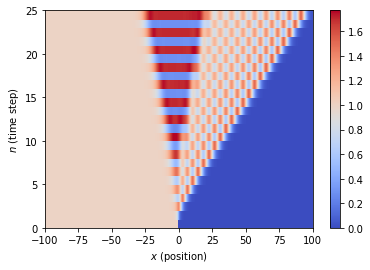

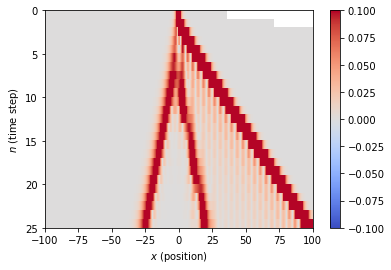

In [15]:
ide = IDE(growth_fn         = ricker(r = 2.5),
             kernel_fn         = laplace())

sim = IDESimulation(ide       = ide,
                    initial_condition = lambda x: np.heaviside(x, 1),
                    num_iters = 25,
                    domain_size = 200,  
                    step_size = 0.05)

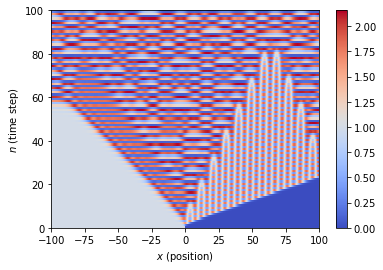

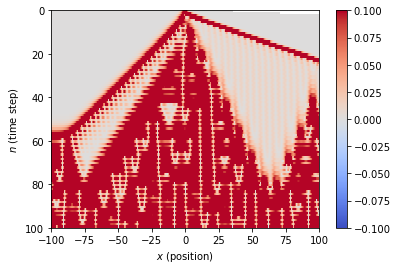

In [16]:
ide = IDE(growth_fn         = ricker(r = 2.8),
             kernel_fn         = laplace())

sim = IDESimulation(ide       = ide,
                    initial_condition = lambda x: np.heaviside(x, 1),
                    num_iters = 100,
                   domain_size = 200,  
                    step_size = 0.05)

In [18]:
rickera = lambda r, a: lambda u: u * np.exp(r * (1 - u)) * np.heaviside(u - a, 1)

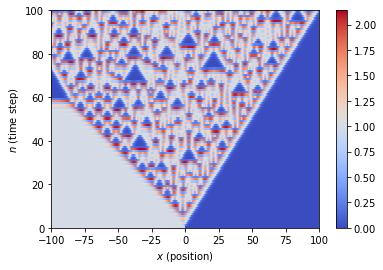

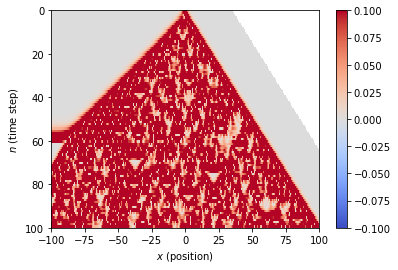

In [19]:
ide = IDE(growth_fn         = rickera(r = 2.8, a = 0.3),
             kernel_fn         = laplace())

sim = IDESimulation(ide       = ide,
                    initial_condition = lambda x: np.heaviside(x, 1),
                    num_iters = 100,
                   domain_size = 200,  
                    step_size = 0.05)

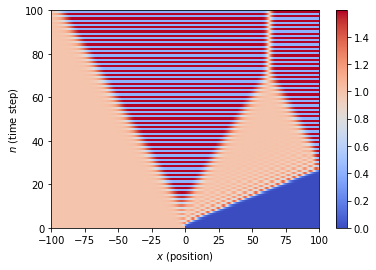

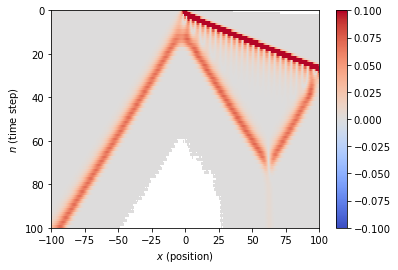

In [20]:
ide = IDE(growth_fn         = rickera(r = 2.3, a = 0.0),
             kernel_fn         = laplace())

sim = IDESimulation(ide       = ide,
                    initial_condition = lambda x: np.heaviside(x, 1),
                    num_iters = 100,
                   domain_size = 200,  
                    step_size = 0.05)

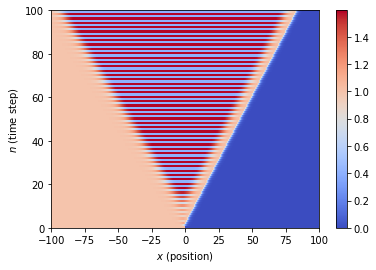

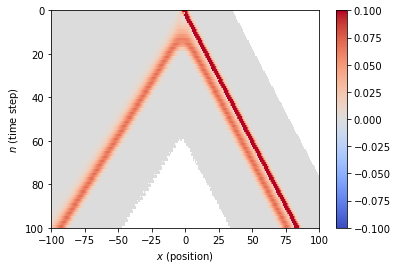

In [21]:
ide = IDE(growth_fn         = rickera(r = 2.3, a = 0.3),
             kernel_fn         = laplace())

sim = IDESimulation(ide       = ide,
                    initial_condition = lambda x: np.heaviside(x, 1),
                    num_iters = 100,
                   domain_size = 200,  
                    step_size = 0.05)

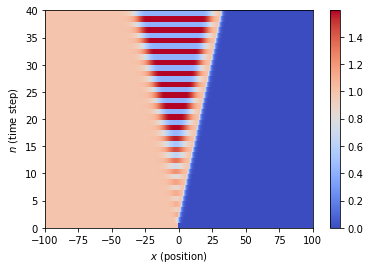

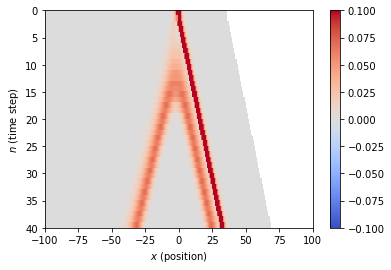

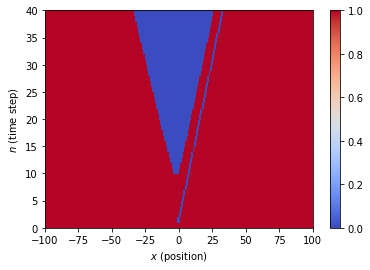

In [22]:
eps = .2
critical_filter = np.vectorize(lambda x : np.heaviside(eps - min([abs(x - a) for a in [0, 1]]), 1))

sim = IDESimulation(ide       = ide,
                    initial_condition = lambda x: np.heaviside(x, 1),
                    num_iters = 40,
                   domain_size = 200,  
                    step_size = 0.05)
sim.results = critical_filter(sim.results)
sim.plot_heatmap()

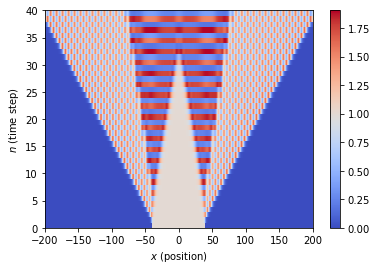

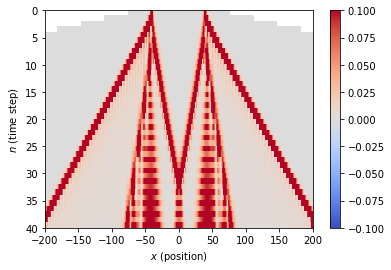

In [24]:
ide = IDE(growth_fn         = rickera(r = 2.6, a = 0.0),
             kernel_fn         = laplace())
sim = IDESimulation(ide       = ide,
                    initial_condition = u0_compact(r=40),
                    num_iters = 40,
                   domain_size = 400,  
                    step_size = 0.05)

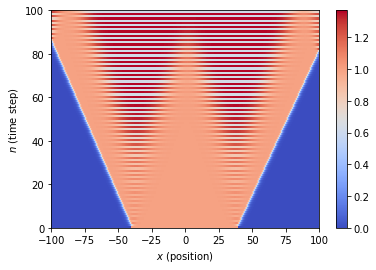

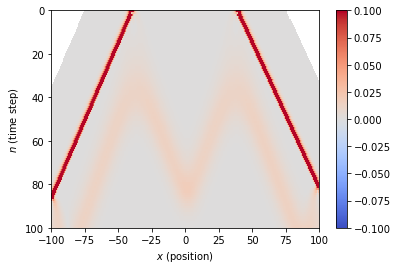

In [25]:
ide = IDE(growth_fn         = rickera(r = 2.1, a = 0.3),
             kernel_fn         = laplace())

sim = IDESimulation(ide       = ide,
                    initial_condition = u0_compact(r=40),
                    num_iters = 100,
                   domain_size = 200,  
                    step_size = 0.05)

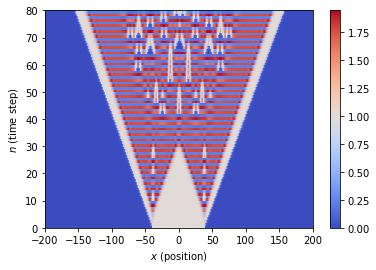

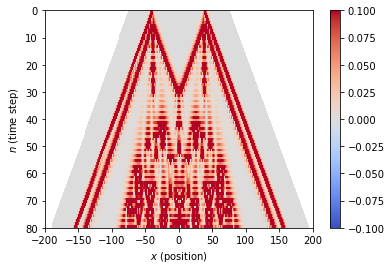

In [26]:
ide = IDE(growth_fn         = rickera(r = 2.65, a = 0.18),
             kernel_fn         = laplace())

sim = IDESimulation(ide       = ide,
                    initial_condition = u0_compact(r=40),
                    num_iters = 80,
                   domain_size = 400,  
                    step_size = 0.05)